In [ ]:
# =============================================================================
# STEP 0: EXTRACT DATASET FROM FRIEND'S SHARED GOOGLE DRIVE
# =============================================================================

def extract_zip_from_shared_drive(zip_path, extract_to="/content/extracted"):
    from google.colab import drive
    import os
    import zipfile

    # Mount YOUR Google Drive
    drive.mount('/content/drive')

    # Verify ZIP exists
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"❌ ZIP file not found: {zip_path}")

    # Create extraction directory
    os.makedirs(extract_to, exist_ok=True)

    print(f"📦 Extracting ZIP:")
    print(f"   Source: {zip_path}")
    print(f"   Target: {extract_to}")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    print("✅ Dataset extracted successfully!")


# ✅ CHANGE ONLY THIS PATH
ZIP_FILE = "/content/drive/MyDrive/project/military_object_dataset.zip"
extract_zip_from_shared_drive(ZIP_FILE)


Mounted at /content/drive
📦 Extracting ZIP:
   Source: /content/drive/MyDrive/project/military_object_dataset.zip
   Target: /content/extracted
✅ Dataset extracted successfully!


In [ ]:
# =============================================================================
# STEP 1: INSTALL DEPENDENCIES
# =============================================================================

!pip install -q ultralytics opencv-python-headless

import os
import yaml
import shutil
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import zipfile
from IPython.display import display, Image as IPImage
import cv2

from ultralytics import YOLO

print("✅ All dependencies installed!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All dependencies installed!


In [ ]:
# =============================================================================
# STEP 2: SET UP PATHS & VERIFY DATASET
# =============================================================================

DATASET_PATH = "/content/extracted/military_object_dataset"
WORK_DIR = "/content/work"

os.makedirs(WORK_DIR, exist_ok=True)

required_dirs = [
    'train/images', 'train/labels',
    'val/images', 'val/labels',
    'test/images'
]

print("\n🔍 Verifying dataset structure...")
valid = True
for d in required_dirs:
    path = Path(DATASET_PATH) / d
    exists = path.exists()
    print(f"{'✅' if exists else '❌'} {d}")
    if not exists:
        valid = False

if not valid:
    print("⚠️ Dataset structure mismatch, using fallback path")
    DATASET_PATH = "/content/extracted"

print(f"\n✅ Final dataset path: {DATASET_PATH}")



🔍 Verifying dataset structure...
✅ train/images
✅ train/labels
✅ val/images
✅ val/labels
✅ test/images

✅ Final dataset path: /content/extracted/military_object_dataset


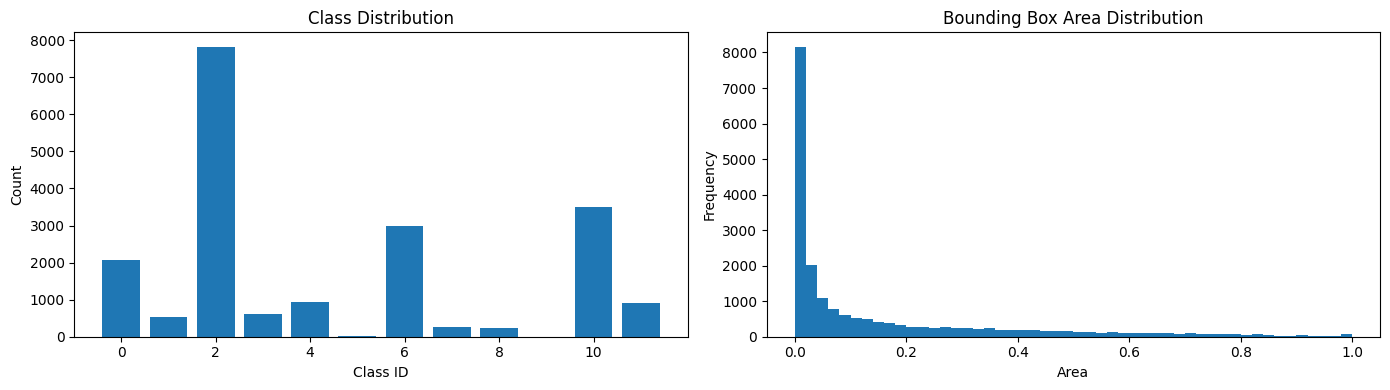

In [ ]:
# =============================================================================
# STEP 3: DATASET ANALYSIS (FIXED FOR EXTRA VALUES)
# =============================================================================

def analyze_dataset(dataset_path):
    from collections import Counter
    from pathlib import Path
    import matplotlib.pyplot as plt

    labels_dir = Path(dataset_path) / 'train/labels'
    class_counts = Counter()
    box_areas = []

    for label_file in labels_dir.glob('*.txt'):
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()

                # ✅ YOLO requires at least 5 values
                if len(parts) < 5:
                    continue

                cls = int(float(parts[0]))
                w = float(parts[3])
                h = float(parts[4])

                class_counts[cls] += 1
                box_areas.append(w * h)

    # ---- Plot results ----
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Class distribution
    axes[0].bar(class_counts.keys(), class_counts.values())
    axes[0].set_title("Class Distribution")
    axes[0].set_xlabel("Class ID")
    axes[0].set_ylabel("Count")

    # Box size distribution
    axes[1].hist(box_areas, bins=50)
    axes[1].set_title("Bounding Box Area Distribution")
    axes[1].set_xlabel("Area")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

    return class_counts


# ✅ Run analysis
class_distribution = analyze_dataset(DATASET_PATH)


In [ ]:
yaml_path = "/content/extracted/military_object_dataset/military_dataset.yaml"

with open(yaml_path, "w") as f:
    f.write(
"""path: /content/extracted/military_object_dataset
train: train/images
val: val/images
test: test/images

names:
  0: camouflage_soldier
  1: weapon
  2: military_tank
  3: military_truck
  4: military_vehicle
  5: civilian
  6: soldier
  7: civilian_vehicle
  8: military_artillery
  9: trench
  10: military_aircraft
  11: military_warship
"""
    )

print("✅ YAML path fixed for Google Colab")


✅ YAML path fixed for Google Colab


In [ ]:
with open(yaml_path) as f:
    print(f.read())


path: /content/extracted/military_object_dataset
train: train/images
val: val/images
test: test/images

names:
  0: camouflage_soldier
  1: weapon
  2: military_tank
  3: military_truck
  4: military_vehicle
  5: civilian
  6: soldier
  7: civilian_vehicle
  8: military_artillery
  9: trench
  10: military_aircraft
  11: military_warship



In [ ]:
# # ✅ Use existing YAML file (already provided with dataset)
# YAML_PATH = "/content/extracted/military_object_dataset/military_dataset.yaml"

# # Quick verification
# with open(YAML_PATH) as f:
#     print("📄 YAML CONFIG:\n")
#     print(f.read())


📄 YAML CONFIG:

path: /kaggle/input/military-assets-dataset-12-classes-yolo8-format/military_object_dataset
test: test/images
train: train/images
val: val/images

names:
  0: camouflage_soldier
  1: weapon
  2: military_tank
  3: military_truck
  4: military_vehicle
  5: civilian
  6: soldier
  7: civilian_vehicle
  8: military_artillery
  9: trench
  10: military_aircraft
  11: military_warship



In [ ]:
from ultralytics import YOLO
import os
from pathlib import Path

MODEL_NAME = "yolov8m.pt"   # change to yolov8s.pt if GPU memory is low
EPOCHS =40
BATCH_SIZE = 16
IMG_SIZE = 640

WORK_DIR = "/content/work"
os.makedirs(WORK_DIR, exist_ok=True)

print("🚀 Initializing YOLO model...")
model = YOLO(MODEL_NAME)

print("🔥 Starting training...")
results = model.train(
    data=YAML_PATH,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    device=0,
    patience=20,
    optimizer="AdamW",
    amp=True,
    project=f"{WORK_DIR}/training",
    name="run",
    exist_ok=True
)

print("✅ Training completed successfully!")


🚀 Initializing YOLO model...
🔥 Starting training...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/extracted/military_object_dataset/military_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=run, nbs=64, nms=False, opset=None, optimize=False, op

In [ ]:
# =============================================================================
# STEP 6: VALIDATION
# =============================================================================

train_dir = Path(WORK_DIR) / "training/run"
best_model = train_dir / "weights/best.pt"

model = YOLO(str(best_model))

metrics = model.val(
    data=str(yaml_path),
    imgsz=IMG_SIZE,
    batch=16,
    device=0
)

print(f"📊 mAP@50: {metrics.box.map50:.4f}")


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,846,708 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1851.2±629.6 MB/s, size: 92.5 KB)
val: Scanning /content/extracted/military_object_dataset/val/labels.cache... 2941 images, 273 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2941/2941 4.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 184/184 2.6it/s 1:10
                   all       2941       5081      0.682      0.424      0.456      0.288
    camouflage_soldier        385        510      0.737      0.654      0.726      0.372
                weapon        222        358      0.735      0.474      0.534      0.371
         military_tank        938       1787      0.779      0.833       0.83      0.558
        military_truck         84        148      0.478      0.574      0.546       0.31
      military_ve

In [ ]:
# =============================================================================
# STEP 7: PREDICTIONS ON TEST SET
# =============================================================================

pred_dir = Path(WORK_DIR) / "predictions"
pred_dir.mkdir(exist_ok=True)

test_images = list((Path(DATASET_PATH) / 'test/images').glob('*'))

for img in tqdm(test_images):
    r = model.predict(img, conf=0.25, save=False)[0]
    out = pred_dir / f"{img.stem}.txt"

    with open(out, 'w') as f:
        if r.boxes:
            for b in r.boxes:
                cls = int(b.cls)
                conf = float(b.conf)
                x1,y1,x2,y2 = b.xyxy[0]
                w,h = r.orig_shape[1], r.orig_shape[0]
                xc,yc = ((x1+x2)/2)/w, ((y1+y2)/2)/h
                bw,bh = (x2-x1)/w, (y2-y1)/h
                f.write(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f} {conf:.6f}\n")

print("✅ Predictions completed!")


  0%|          | 0/1396 [00:00<?, ?it/s]


image 1/1 /content/extracted/military_object_dataset/test/images/013586.jpg: 640x640 1 military_tank, 37.0ms
Speed: 2.2ms preprocess, 37.0ms inference, 5.6ms postprocess per image at shape (1, 3, 640, 640)


  0%|          | 1/1396 [00:00<03:44,  6.21it/s]


image 1/1 /content/extracted/military_object_dataset/test/images/002904.jpg: 640x640 1 camouflage_soldier, 37.0ms
Speed: 1.9ms preprocess, 37.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/extracted/military_object_dataset/test/images/005959.jpg: 640x640 1 camouflage_soldier, 37.0ms
Speed: 1.5ms preprocess, 37.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


  0%|          | 3/1396 [00:00<01:50, 12.61it/s]

...


image 1/1 /content/extracted/military_object_dataset/test/images/008987.jpg: 416x640 1 military_tank, 20.9ms
Speed: 3.8ms preprocess, 20.9ms inference, 3.7ms postprocess per image at shape (1, 3, 416, 640)

image 1/1 /content/extracted/military_object_dataset/test/images/017050.jpg: 512x640 2 military_tanks, 14.0ms
Speed: 3.7ms preprocess, 14.0ms inference, 1.7ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /content/extracted/military_object_dataset/test/images/008755.jpg: 448x640 1 military_tank, 14.2ms
Speed: 3.6ms preprocess, 14.2ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


100%|█████████▉| 1392/1396 [00:49<00:00, 26.82it/s]


image 1/1 /content/extracted/military_object_dataset/test/images/013620.jpg: 640x640 1 military_tank, 19.2ms
Speed: 2.3ms preprocess, 19.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/extracted/military_object_dataset/test/images/005947.jpg: 640x640 1 camouflage_soldier, 17.9ms
Speed: 2.2ms preprocess, 17.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/extracted/military_object_dataset/test/images/017094.jpg: 352x640 3 military_tanks, 15.2ms
Speed: 3.3ms preprocess, 15.2ms inference, 1.9ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/extracted/military_object_dataset/test/images/000020.jpg: 640x640 2 camouflage_soldiers, 18.9ms
Speed: 2.0ms preprocess, 18.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


100%|██████████| 1396/1396 [00:49<00:00, 27.99it/s]

✅ Predictions completed!


In [ ]:
# =============================================================================
# STEP 8: CREATE SUBMISSION ZIP
# =============================================================================

submission_zip = f"{WORK_DIR}/submission.zip"

with zipfile.ZipFile(submission_zip, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in pred_dir.glob("*.txt"):
        z.write(f, f.name)

print(f"✅ Submission ZIP ready: {submission_zip}")


✅ Submission ZIP ready: /content/work/submission.zip


In [ ]:
# =============================================================================
# STEP 9: DOWNLOAD FILES
# =============================================================================

from google.colab import files

files.download(submission_zip)
files.download(str(best_model))

print("🎉 ALL DONE!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 ALL DONE!
